**setup**

In [ ]:
import os
from google.colab import userdata, drive

# Mount Google Drive
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/fer_challenge/'
os.makedirs(SAVE_DIR, exist_ok=True)

# Kaggle
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_KEY')
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')

# Install required packages
!pip install wandb kaggle -q

# Authenticate and login to WANDB
import wandb
wandb.login(key=userdata.get('WANDB_API_KEY'))

print("Setup completed successfully.")

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: akeke23 (akeke23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Setup completed successfully.


In [ ]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 7.4 MB/s eta 0:00:00


In [ ]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
!unzip -q -o challenges-in-representation-learning-facial-expression-recognition-challenge.zip
!ls -la

100% 285M/285M [00:08<00:00, 36.6MB/s]

total 974064
drwxr-xr-x 1 root root      4096 Jun 14 21:13 .
drwxr-xr-x 1 root root      4096 Jun 14 20:10 ..
-rw-r--r-- 1 root root 299063632 Dec 11  2019 challenges-in-representation-learning-facial-expression-recognition-challenge.zip
drwxr-xr-x 4 root root      4096 Jun  4 13:32 .config
drwx------ 5 root root      4096 Jun 14 21:12 drive
-rw-r--r-- 1 root root      7178 Dec 11  2019 example_submission.csv
-rw-r--r-- 1 root root  96433867 Dec 11  2019 fer2013.tar.gz
-rw-r--r-- 1 root root 301072768 Dec 11  2019 icml_face_data.csv
drwxr-xr-x 1 root root      4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root  60125203 Dec 11  2019 test.csv
-rw-r--r-- 1 root root 240699943 Dec 11  2019 train.csv


In [ ]:
!cp /content/train.csv "{SAVE_DIR}"
!cp /content/test.csv "{SAVE_DIR}"
!cp /content/example_submission.csv "{SAVE_DIR}"

**eda**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv(f'{SAVE_DIR}/train.csv')
test_df  = pd.read_csv(f'{SAVE_DIR}/test.csv')

EMOTIONS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Basic dataset overview
print("Dataset Size")
print(f"Train: {len(train_df):,} images")
print(f"Test:  {len(test_df):,} images")

print(f"\nColumns")
print(train_df.dtypes)

print(f"\nFirst 3 rows")
print(train_df.head(3))

Dataset Size
Train: 28,709 images
Test:  7,178 images

Columns
emotion     int64
pixels     object
dtype: object

First 3 rows
   emotion                                             pixels
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1        0  151 150 147 155 148 133 111 140 170 174 182 15...
2        2  231 212 156 164 174 138 161 173 182 200 106 38...


In [ ]:
# Class distribution analysis
counts = train_df['emotion'].value_counts().sort_index()

print("Class Distribution")
for i, emotion in enumerate(EMOTIONS):
    print(f"{emotion:<10}: {counts[i]:>5} images ({counts[i]/len(train_df)*100:.1f}%)")

Class Distribution
Angry     :  3995 images (13.9%)
Disgust   :   436 images (1.5%)
Fear      :  4097 images (14.3%)
Happy     :  7215 images (25.1%)
Sad       :  4830 images (16.8%)
Surprise  :  3171 images (11.0%)
Neutral   :  4965 images (17.3%)


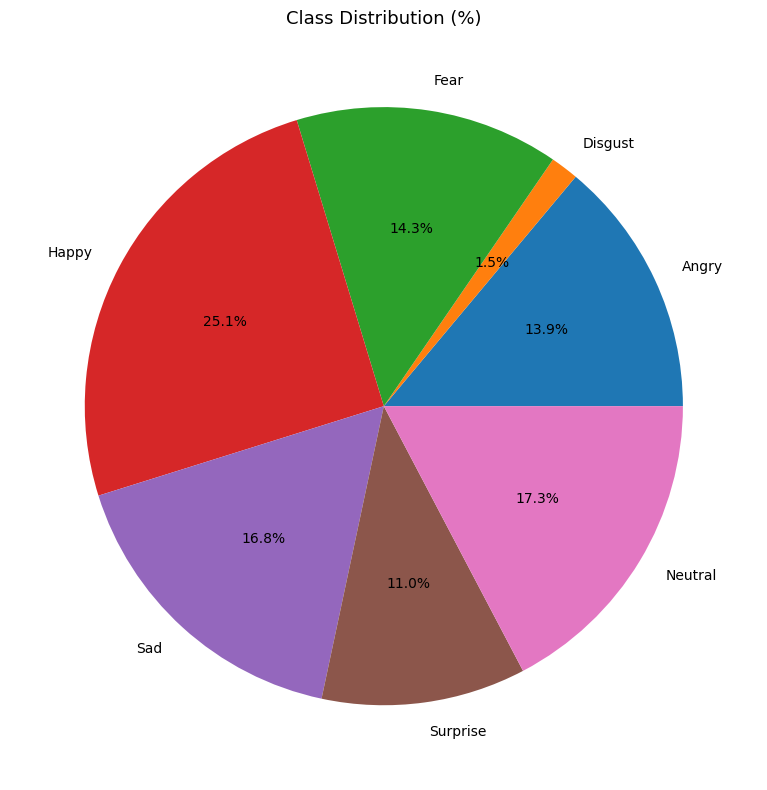

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

explode = [0, 0, 0, 0, 0, 0, 0]
ax.pie(counts.values, labels=EMOTIONS, autopct='%1.1f%%', explode=explode)
ax.set_title('Class Distribution (%)', fontsize=13)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

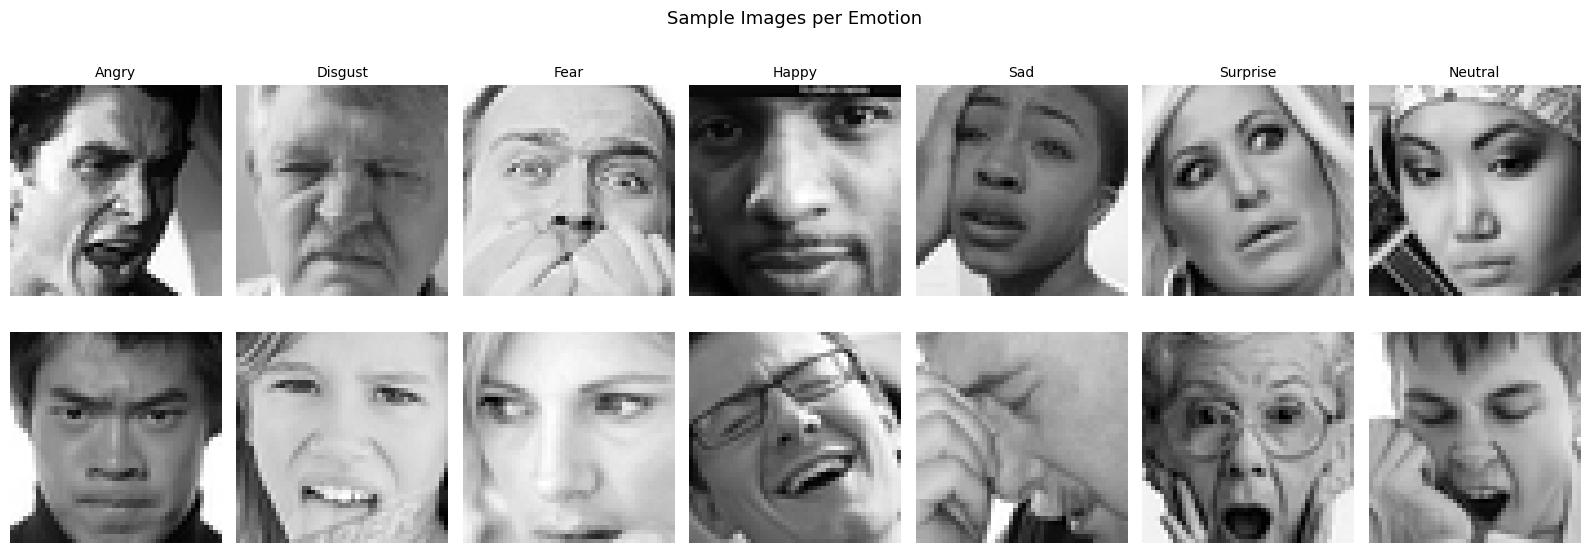

In [ ]:
fig, axes = plt.subplots(2, 7, figsize=(16, 6))

for col in range(7):
    samples = train_df[train_df['emotion'] == col].sample(2, random_state=42)

    for row, (_, sample) in enumerate(samples.iterrows()):
        img = np.fromstring(sample['pixels'], sep=' ').reshape(48, 48)
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(EMOTIONS[col], fontsize=10)

plt.suptitle('Sample Images per Emotion', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/eda_samples.png', dpi=150, bbox_inches='tight')
plt.show()

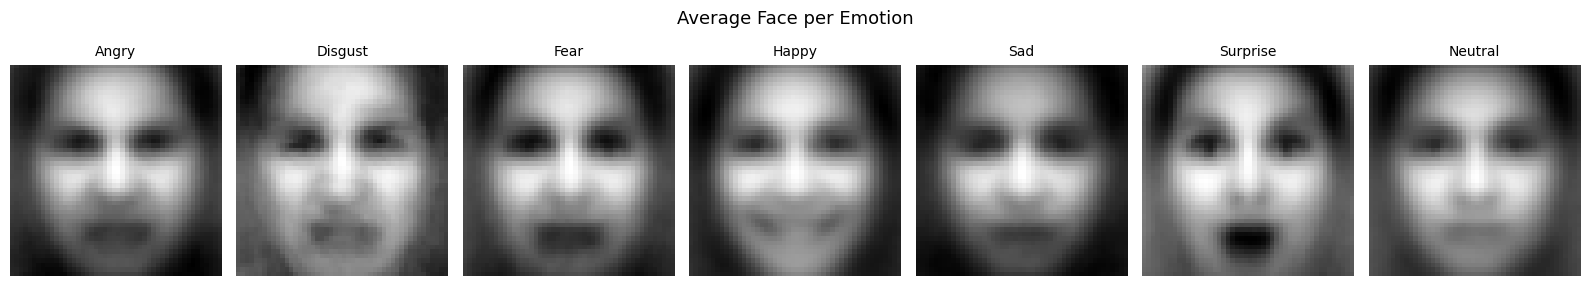

In [ ]:
fig, axes = plt.subplots(1, 7, figsize=(16, 3))

for i in range(7):
    pixels = train_df[train_df['emotion'] == i]['pixels'].apply(
        lambda x: np.fromstring(x, sep=' ').reshape(48, 48)
    )
    mean_img = np.stack(pixels.values).mean(axis=0)
    axes[i].imshow(mean_img, cmap='gray')
    axes[i].set_title(EMOTIONS[i], fontsize=10)
    axes[i].axis('off')

plt.suptitle('Average Face per Emotion', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/eda_mean_faces.png', dpi=150, bbox_inches='tight')
plt.show()

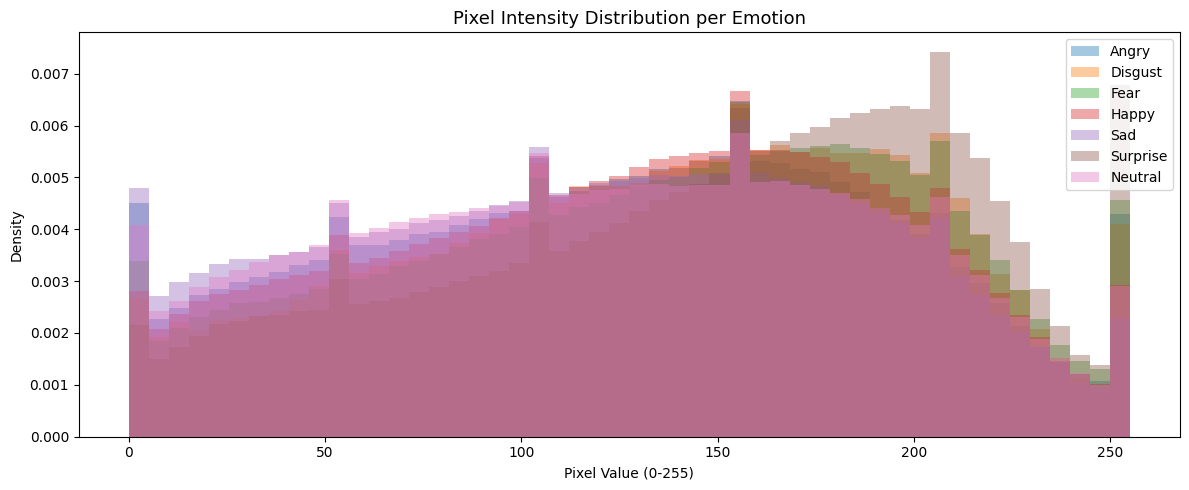

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

for i in range(7):
    pixels = train_df[train_df['emotion'] == i]['pixels'].apply(
        lambda x: np.fromstring(x, sep=' ')
    )
    all_pixels = np.concatenate(pixels.values)
    ax.hist(all_pixels, bins=50, alpha=0.4, label=EMOTIONS[i], density=True)

ax.set_title('Pixel Intensity Distribution per Emotion', fontsize=13)
ax.set_xlabel('Pixel Value (0-255)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/eda_pixel_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Sample pixel statistics
sample_pixels = train_df['pixels'].apply(
    lambda x: np.fromstring(x, sep=' ')
)

all_pixels = np.concatenate(sample_pixels.values)

print("Pixel Statistics")
print(f"Mean:   {all_pixels.mean():.2f}")
print(f"Std:    {all_pixels.std():.2f}")
print(f"Min:    {all_pixels.min():.2f}")
print(f"Max:    {all_pixels.max():.2f}")

Pixel Statistics
Mean:   129.47
Std:    65.03
Min:    0.00
Max:    255.00
